# Stage B validation — RF vs kriging vs regression-kriging head-to-head

Side-by-side comparison of the three gap-fill candidates against AERONET:
- **`rf`** — B2 covariate-only Random Forest.
- **`kriging`** — B1 ST kriging of the (AOD − CAMS) residual.
- **`rf_rk`** — B3 regression kriging: RF drift + kriged RF residual. Should
  inherit kriging's accuracy near observations *and* the RF baseline in deep
  gaps (kriged correction → 0 ⇒ falls back to ŷ_rf).

Two flavours of comparison:
1. **Side-by-side panels** — independent metric panels for each candidate.
2. **Paired skill** — restricts to *identical* `(slot, site)` keys present in both candidates, then runs a paired t-test on `|error|`.  Avoids the trap where one candidate is graded on easier days than the other.

In [1]:
from datetime import date
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import validate as vb
import config as cfg

START = cfg.TEST_START
END   = cfg.TEST_END
print(f'Held-out window: {START} → {END}')

Held-out window: 2025-01-01 → 2026-04-30


## Extract blind pairs for both candidates

In [2]:
pairs_rf = vb.aeronet_pairs(START, END, candidate='rf',      blind_only=True)
pairs_kr = vb.aeronet_pairs(START, END, candidate='kriging', blind_only=True)
pairs_rk = vb.aeronet_pairs(START, END, candidate='rf_rk',   blind_only=True)
print(f'AERONET-blind pairs — RF: {len(pairs_rf)}, kriging: {len(pairs_kr)}, rf_rk: {len(pairs_rk)}')

AERONET-blind pairs — RF: 636, kriging: 631, rf_rk: 636


## Side-by-side metric panels

`compare_candidates` returns each candidate's full panel plus a `SUMMARY` row with the mean RMSE across `(site, season)` cells.

In [3]:
vb.compare_candidates({'rf': pairs_rf, 'kriging': pairs_kr, 'rf_rk': pairs_rk})

,N,R,R2,RMSE,MAE,Bias,pct_EE,label,site,season,candidate
0,422.0,0.322843,-0.249338,0.157924,0.132946,0.076317,33.649289,site=Bac_Lieu,Bac_Lieu,all,rf
1,214.0,0.764906,0.434822,0.568138,0.323092,-0.086403,40.654206,site=NGHIA_DO,NGHIA_DO,all,rf
2,229.0,0.678136,0.415036,0.125787,0.093213,-0.011142,57.205240,site=Bac_Lieu season=dry,Bac_Lieu,dry,rf
3,193.0,0.576365,-9.752012,0.189099,0.180090,0.180090,5.699482,site=Bac_Lieu season=wet,Bac_Lieu,wet,rf
4,122.0,0.763101,0.357010,0.716258,0.446017,-0.177629,34.426230,site=NGHIA_DO season=dry,NGHIA_DO,dry,rf
5,92.0,0.259130,0.040157,0.265516,0.160083,0.034570,48.913043,site=NGHIA_DO season=wet,NGHIA_DO,wet,rf
6,636.0,0.785667,0.520413,0.353775,0.196926,0.021565,36.006289,ALL,ALL,all,rf
7,417.0,0.236163,-0.535405,0.175589,0.132992,0.070672,39.328537,site=Bac_Lieu,Bac_Lieu,all,kriging
8,214.0,0.855045,0.718569,0.400910,0.261310,-0.012910,35.514019,site=NGHIA_DO,NGHIA_DO,all,kriging
9,224.0,0.465351,0.209592,0.146340,0.110106,-0.002046,52.678571,site=Bac_Lieu season=dry,Bac_Lieu,dry,kriging


## Paired skill — identical `(slot, site)` keys

Reports paired RMSE difference (`rmse_a − rmse_b`) and the paired t-test on absolute errors.  `p_value < 0.05` means the candidates differ significantly on the shared key set.

The two comparisons that matter for B3:
- **`rf_rk` vs `kriging`** — does regression kriging beat the kriging baseline? (negative `rmse_diff` = rf_rk better)
- **`rf_rk` vs `rf`** — how much does the kriged residual add over the bare RF drift?

In [4]:
print('rf_rk vs kriging  (rmse_diff < 0 ⇒ rf_rk better):')
display(vb.paired_skill(pairs_rk, pairs_kr))
print('rf_rk vs rf       (rmse_diff < 0 ⇒ rf_rk better):')
display(vb.paired_skill(pairs_rk, pairs_rf))
print('rf vs kriging     (original baseline comparison):')
display(vb.paired_skill(pairs_rf, pairs_kr))

rf_rk vs kriging  (rmse_diff < 0 ⇒ rf_rk better):


{'n_paired': 631,
 'rmse_a': 0.2854074268370424,
 'rmse_b': 0.2736519636743108,
 'rmse_diff_a_minus_b': 0.011755463162731572,
 't_statistic': 8.842974927480885,
 'p_value': 9.304865451878575e-18}

rf_rk vs rf       (rmse_diff < 0 ⇒ rf_rk better):


{'n_paired': 636,
 'rmse_a': 0.284526297981116,
 'rmse_b': 0.3537750232926401,
 'rmse_diff_a_minus_b': -0.0692487253115241,
 't_statistic': -0.687389439890458,
 'p_value': 0.4920883278943212}

rf vs kriging     (original baseline comparison):


{'n_paired': 631,
 'rmse_a': 0.3549895656550885,
 'rmse_b': 0.2736519636743108,
 'rmse_diff_a_minus_b': 0.08133760198077766,
 't_statistic': 2.4937268549755034,
 'p_value': 0.012896322697413622}

## Scatter — RF vs kriging vs rf_rk vs AERONET

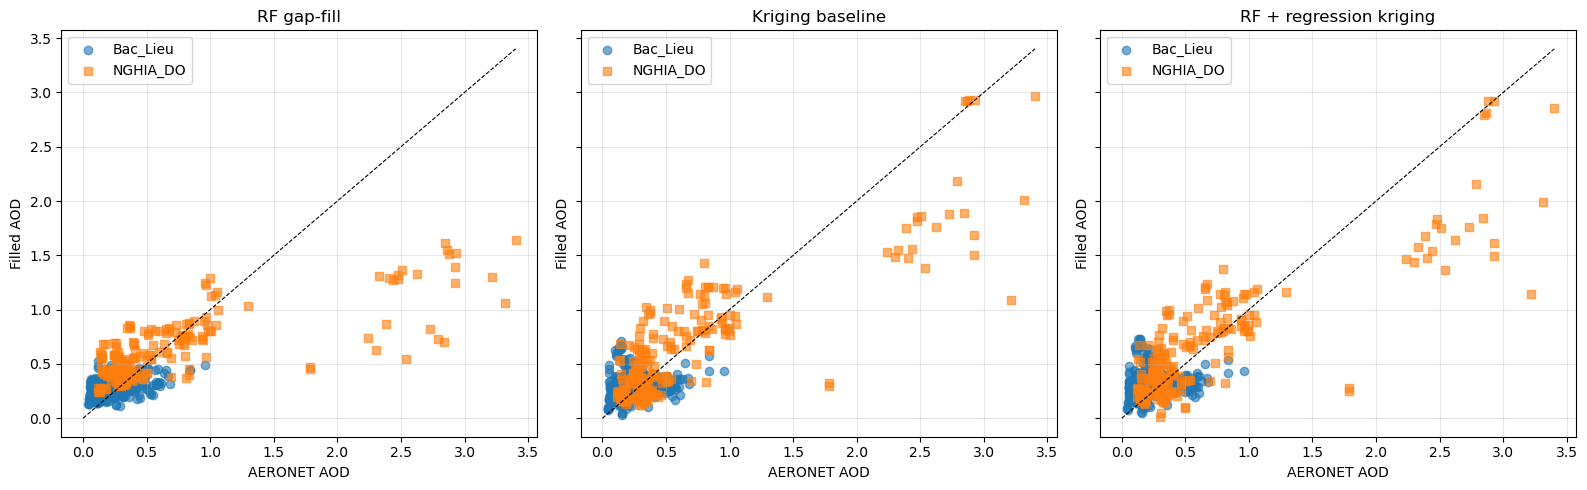

In [5]:
panels = [('RF gap-fill', pairs_rf), ('Kriging baseline', pairs_kr),
          ('RF + regression kriging', pairs_rk)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (label, df) in zip(axes, panels):
    if df.empty:
        ax.set_title(f'{label}: no matched pairs'); ax.set_visible(False); continue
    for site, marker in zip(df['site'].unique(), ('o', 's', '^', 'D')):
        sub = df[df['site'] == site]
        ax.scatter(sub['aer_aod'], sub['sat_aod'], alpha=0.6, label=site, marker=marker)
    lim = max(df[['aer_aod', 'sat_aod']].max().max(), 1.0)
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8)
    ax.set_xlabel('AERONET AOD'); ax.set_ylabel('Filled AOD'); ax.set_title(label)
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()